In [64]:
%pip install seaborn
%pip install plotly
%pip install scipy
%pip install pandas



In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.cluster import KMeans
from scipy.cluster import hierarchy as sch
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [66]:
df=pd.read_csv('TUFE.excel.csv')

In [67]:
df.head()

,TÜFE (Yıllık % Değişim),TÜFE (Yıllık % Değişim)2,TÜFE (Aylık % Değişim)
0,12/1/2024,4438%,1.03%
1,11/1/2024,47.09%,2.24%
2,10/1/2024,48.58%,2.88%
3,9/1/2024,49.38%,2.97%
4,8/1/2024,51.97%,2.47%


In [68]:
df=pd.DataFrame(df)

In [69]:
df.iloc[0, 1] = "44.38"

In [70]:
print(df)

   TÜFE (Yıllık % Değişim) TÜFE (Yıllık % Değişim)2 TÜFE (Aylık % Değişim)
0                12/1/2024                    44.38                  1.03%
1                11/1/2024                   47.09%                  2.24%
2                10/1/2024                   48.58%                  2.88%
3                 9/1/2024                   49.38%                  2.97%
4                 8/1/2024                   51.97%                  2.47%
5                 7/1/2024                   61.78%                  3.23%
6                 6/1/2024                   71.60%                  1.64%
7                 5/1/2024                   75.45%                  3.37%
8                 4/1/2024                   69.80%                  3.18%
9                 3/1/2024                   68.50%                  3.16%
10                2/1/2024                   67.07%                  4.53%
11                1/1/2024                   64.86%                  6.70%


In [71]:
# convert all columns and divide by 100
df['TÜFE (Yıllık % Değişim)2'] = df['TÜFE (Yıllık % Değişim)2'].str.replace('%', '').str.strip()

In [72]:
print(df)

   TÜFE (Yıllık % Değişim) TÜFE (Yıllık % Değişim)2 TÜFE (Aylık % Değişim)
0                12/1/2024                    44.38                  1.03%
1                11/1/2024                    47.09                  2.24%
2                10/1/2024                    48.58                  2.88%
3                 9/1/2024                    49.38                  2.97%
4                 8/1/2024                    51.97                  2.47%
5                 7/1/2024                    61.78                  3.23%
6                 6/1/2024                    71.60                  1.64%
7                 5/1/2024                    75.45                  3.37%
8                 4/1/2024                    69.80                  3.18%
9                 3/1/2024                    68.50                  3.16%
10                2/1/2024                    67.07                  4.53%
11                1/1/2024                    64.86                  6.70%


In [73]:
df.rename(columns={'TÜFE (Yıllık % Değişim)': 'AYLAR'}, inplace=True)

In [74]:
print(df)

        AYLAR TÜFE (Yıllık % Değişim)2 TÜFE (Aylık % Değişim)
0   12/1/2024                    44.38                  1.03%
1   11/1/2024                    47.09                  2.24%
2   10/1/2024                    48.58                  2.88%
3    9/1/2024                    49.38                  2.97%
4    8/1/2024                    51.97                  2.47%
5    7/1/2024                    61.78                  3.23%
6    6/1/2024                    71.60                  1.64%
7    5/1/2024                    75.45                  3.37%
8    4/1/2024                    69.80                  3.18%
9    3/1/2024                    68.50                  3.16%
10   2/1/2024                    67.07                  4.53%
11   1/1/2024                    64.86                  6.70%


In [75]:
df.head()

,AYLAR,TÜFE (Yıllık % Değişim)2,TÜFE (Aylık % Değişim)
0,12/1/2024,44.38,1.03%
1,11/1/2024,47.09,2.24%
2,10/1/2024,48.58,2.88%
3,9/1/2024,49.38,2.97%
4,8/1/2024,51.97,2.47%


In [76]:
df.shape

(12, 3)

In [77]:
df.tail

<bound method NDFrame.tail of         AYLAR TÜFE (Yıllık % Değişim)2 TÜFE (Aylık % Değişim)
0   12/1/2024                    44.38                  1.03%
1   11/1/2024                    47.09                  2.24%
2   10/1/2024                    48.58                  2.88%
3    9/1/2024                    49.38                  2.97%
4    8/1/2024                    51.97                  2.47%
5    7/1/2024                    61.78                  3.23%
6    6/1/2024                    71.60                  1.64%
7    5/1/2024                    75.45                  3.37%
8    4/1/2024                    69.80                  3.18%
9    3/1/2024                    68.50                  3.16%
10   2/1/2024                    67.07                  4.53%
11   1/1/2024                    64.86                  6.70%>

In [78]:
df.describe().T

,count,unique,top,freq
AYLAR,12,12,12/1/2024,1
TÜFE (Yıllık % Değişim)2,12,12,44.38,1
TÜFE (Aylık % Değişim),12,12,1.03%,1


In [79]:
df.isnull().sum()

AYLAR                       0
TÜFE (Yıllık % Değişim)2    0
TÜFE (Aylık % Değişim)      0
dtype: int64

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   AYLAR                     12 non-null     object
 1   TÜFE (Yıllık % Değişim)2  12 non-null     object
 2   TÜFE (Aylık % Değişim)    12 non-null     object
dtypes: object(3)
memory usage: 216.0+ bytes


In [81]:
df.columns


Index(['AYLAR', 'TÜFE (Yıllık % Değişim)2', 'TÜFE (Aylık % Değişim)'], dtype='object')

***VISUALIZATION FOR TUFE DATAS***

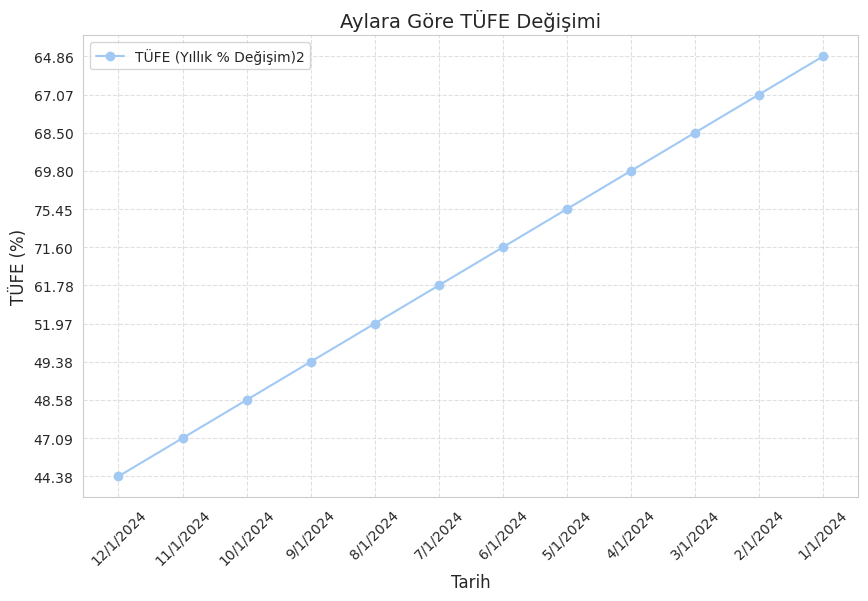

In [82]:
plt.figure(figsize=(10, 6))
plt.plot(df['AYLAR'], df['TÜFE (Yıllık % Değişim)2'], marker='o', label='TÜFE (Yıllık % Değişim)2')
plt.title('Aylara Göre TÜFE Değişimi', fontsize=14)
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('TÜFE (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

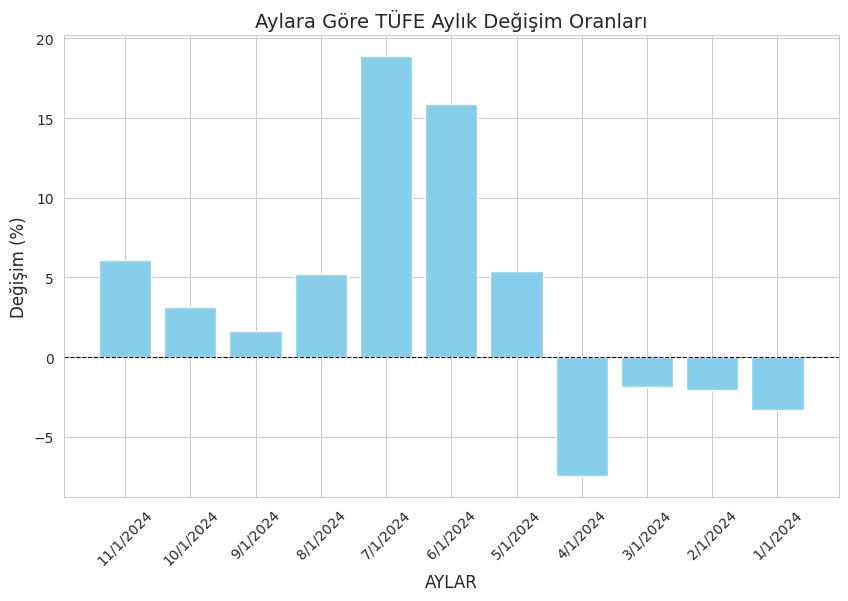

In [83]:
df['TÜFE (Yıllık % Değişim)2'] = pd.to_numeric(df['TÜFE (Yıllık % Değişim)2'], errors='coerce')

df['TÜFE Aylık Değişim'] = df['TÜFE (Yıllık % Değişim)2'].pct_change() * 100

plt.figure(figsize=(10, 6))
plt.bar(df['AYLAR'], df['TÜFE Aylık Değişim'], color='skyblue')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Aylara Göre TÜFE Aylık Değişim Oranları', fontsize=14)
plt.xlabel('AYLAR', fontsize=12)
plt.ylabel('Değişim (%)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [84]:
df['Hareketli Ortalama'] = df['TÜFE (Yıllık % Değişim)2'].rolling(window=3).mean()


In [85]:
sns.set_style('whitegrid')
sns.set_palette('pastel')
print(df)

        AYLAR  TÜFE (Yıllık % Değişim)2 TÜFE (Aylık % Değişim)  \
0   12/1/2024                     44.38                  1.03%   
1   11/1/2024                     47.09                  2.24%   
2   10/1/2024                     48.58                  2.88%   
3    9/1/2024                     49.38                  2.97%   
4    8/1/2024                     51.97                  2.47%   
5    7/1/2024                     61.78                  3.23%   
6    6/1/2024                     71.60                  1.64%   
7    5/1/2024                     75.45                  3.37%   
8    4/1/2024                     69.80                  3.18%   
9    3/1/2024                     68.50                  3.16%   
10   2/1/2024                     67.07                  4.53%   
11   1/1/2024                     64.86                  6.70%   

    TÜFE Aylık Değişim  Hareketli Ortalama  
0                  NaN                 NaN  
1             6.106354                 NaN  
2     

***UFE ANALYSİS***

In [86]:
df_ufe=pd.read_csv('UFE.csv')

In [87]:
df_ufe.head()

,AYLAR,Aylık Değişim,YıllıkDeğişim
0,12/1/2024,0.40,28.52
1,11/1/2024,0.66,29.47
2,10/1/2024,1.29,32.24
3,9/1/2024,1.37,33.09
4,8/1/2024,1.68,35.75


In [88]:
df_ufe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AYLAR          12 non-null     object 
 1   Aylık Değişim  12 non-null     float64
 2   YıllıkDeğişim  12 non-null     float64
dtypes: float64(2), object(1)
memory usage: 312.0+ bytes


In [89]:
df_ufe.shape

(12, 3)

In [90]:
df_ufe.describe().T

,count,mean,std,min,25%,50%,75%,max
Aylık Değişim,12.0,2.120833,1.257873,0.40,1.3500,1.810,3.3675,4.14
YıllıkDeğişim,12.0,42.235833,10.324552,28.52,32.8775,42.785,50.4350,57.68


In [91]:
df_ufe.isnull().sum()

AYLAR            0
Aylık Değişim    0
YıllıkDeğişim    0
dtype: int64

In [92]:
df_ufe.columns

Index(['AYLAR', 'Aylık Değişim', 'YıllıkDeğişim'], dtype='object')

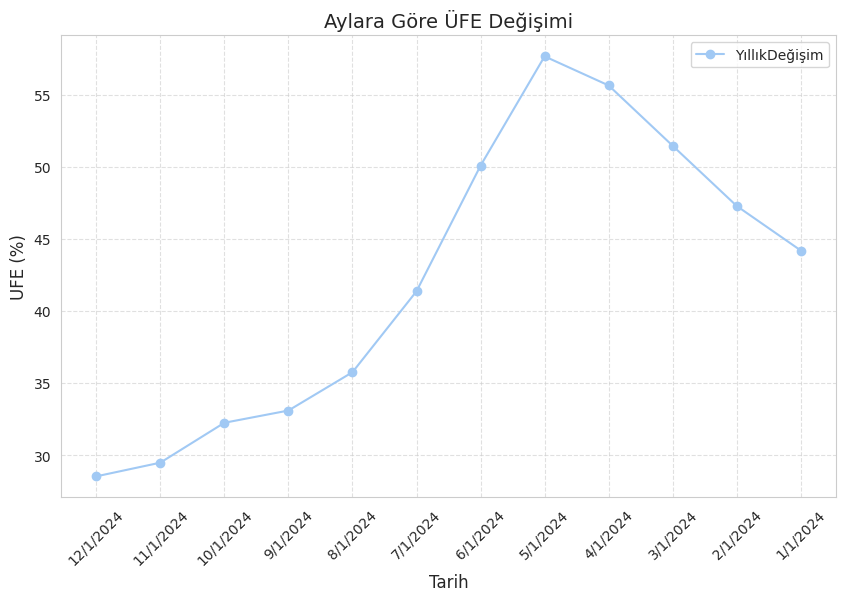

In [93]:
plt.figure(figsize=(10, 6))
plt.plot(df_ufe['AYLAR'], df_ufe['YıllıkDeğişim'], marker='o', label='YıllıkDeğişim')
plt.title('Aylara Göre ÜFE Değişimi', fontsize=14)
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('UFE (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

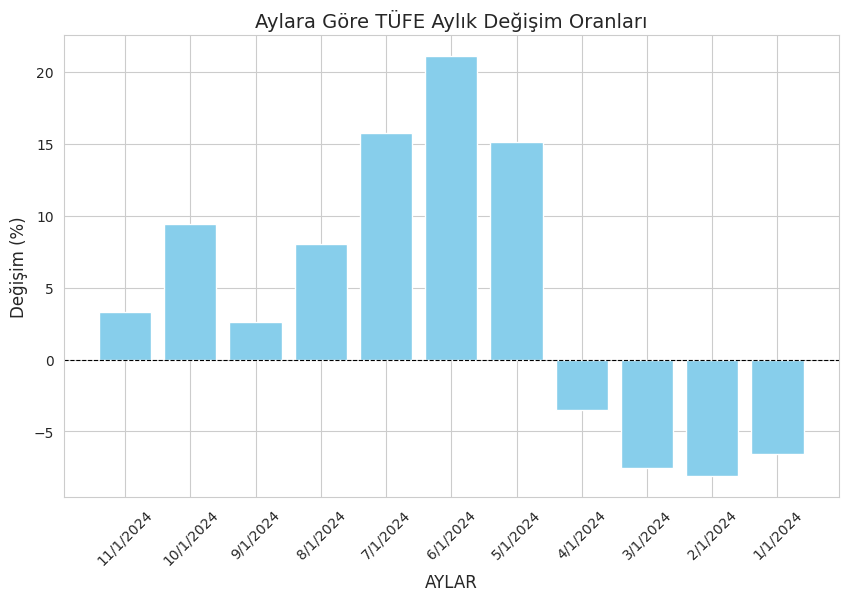

In [94]:
df_ufe['Aylık Değişim'] = df_ufe['YıllıkDeğişim'].pct_change() * 100

plt.figure(figsize=(10, 6))
plt.bar(df_ufe['AYLAR'], df_ufe['Aylık Değişim'], color='skyblue')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Aylara Göre TÜFE Aylık Değişim Oranları', fontsize=14)
plt.xlabel('AYLAR', fontsize=12)
plt.ylabel('Değişim (%)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

***Comparison of PPI and CPI data***

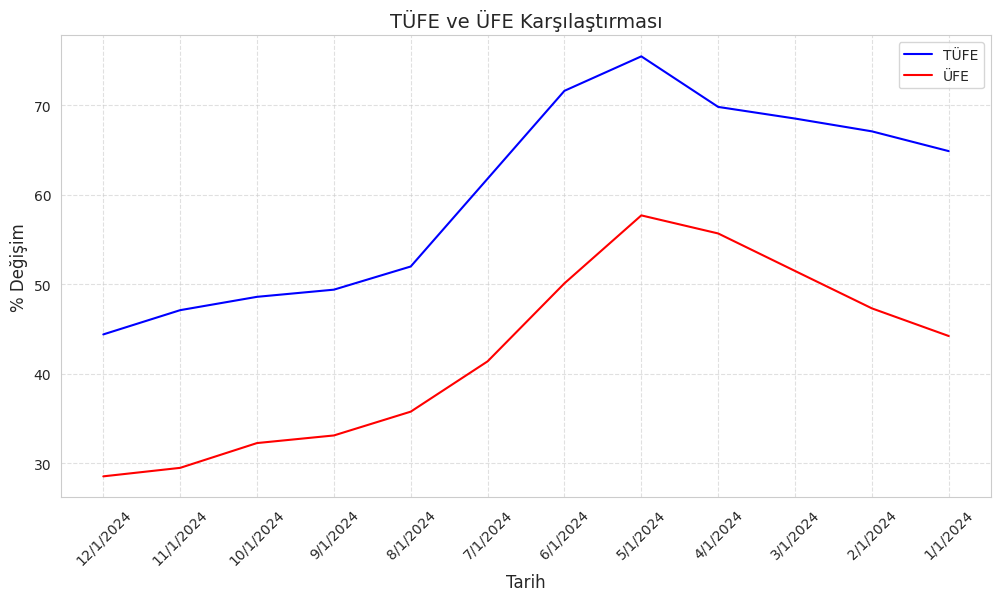

In [95]:

plt.figure(figsize=(12, 6))

# TÜFE ve ÜFE'yi çizme
plt.plot(df['AYLAR'], df['TÜFE (Yıllık % Değişim)2'], label='TÜFE', color='blue')
plt.plot(df_ufe['AYLAR'], df_ufe['YıllıkDeğişim'], label='ÜFE', color='red')

# Başlık ve etiketler
plt.title('TÜFE ve ÜFE Karşılaştırması', fontsize=14)
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('% Değişim', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.show()


In [96]:
correlation = df['TÜFE (Yıllık % Değişim)2'].corr(df_ufe['YıllıkDeğişim'])
print(f"TÜFE ve ÜFE arasındaki korelasyon: {correlation}")


TÜFE ve ÜFE arasındaki korelasyon: 0.9792322077266574


In [97]:
data = pd.DataFrame({
    'TÜFE': df['TÜFE (Yıllık % Değişim)2'],
    'ÜFE': df_ufe['YıllıkDeğişim']
})

In [98]:
data = pd.DataFrame({
    'TÜFE': df['TÜFE (Yıllık % Değişim)2'],
    'ÜFE': df_ufe['YıllıkDeğişim']
})

***PREDICTION ANALYSİS***

In [99]:
#TUFE PREDICTION

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Create Model
model = SARIMAX(df['TÜFE (Yıllık % Değişim)2'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
results = model.fit()

# Predict
forecast = results.forecast(steps=12)
print(forecast)


12     87.050011
13     89.760011
14     91.250011
15     92.050011
16     94.640011
17    104.450011
18    114.270011
19    118.120011
20    112.470011
21    111.170011
22    109.740011
23    107.530011
Name: predicted_mean, dtype: float64


In [100]:
#ufe prediction with SARIMAX

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Create a model
model = SARIMAX(df_ufe['YıllıkDeğişim'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
results = model.fit()

# Predict:
forecast = results.forecast(steps=12)
print(forecast)


12    58.460007
13    59.410007
14    62.180007
15    63.030007
16    65.690007
17    71.310007
18    80.030007
19    87.620007
20    85.600007
21    81.410007
22    77.230007
23    74.140007
Name: predicted_mean, dtype: float64
